## **Business Data Analysis Pipeline**
### *Technical Objective:*
#### This project is an exploration of a common data science workflow and a tour through modern tools used in industry.
 * Python: General purpose programming language, central to most modern data science workflows
 * pandas: Data analysis and manipulation tool used to clean and transform the dataset
 * matplotlib: Visualization tool used to plot and present data
 * scikit-learn: Machine learning tool used to train and validate a model
 * SQLite: Lightweight relational database built into python, used to query data with SQL
 * Claude API: Anthropic's LLM API, used to present plain-English summaries of the dataset

### *Exploration Objective*
#### A customer churn database will be used. Churn is a business term used to describe when a customer stops engaging with a service. Understanding what causes churn within a business is crucial for a company's customer retention and overall performance, and one of the best ways to go about understanding is using data to attempt to explain the churn. This exploration will achieve this goal with the following:
* Use real company data, [Telco Customer Churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn/data)
* Package the data into a relational database so it can be queried with SQL
* Train an ML model to predict whether a customer will churn
* Present findings with graphs and plain-English

---
### **Step One: Fetch data and load it with pandas**

In [1]:
import pandas as pd
import os
import kagglehub

dataset_path = kagglehub.dataset_download("blastchar/telco-customer-churn")
print(dataset_path)

/home/flp/.cache/kagglehub/datasets/blastchar/telco-customer-churn/versions/1


In [2]:
files = os.listdir(dataset_path)
df = pd.read_csv(os.path.join(dataset_path, files[0]))
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


---
### **Step Two: Clean up the data**

#### When cleaning data, it is a necessary to first understand the data. A good way to do it is by running df.info(). This function will print the columns, the number of non-null (i.e. existing) values, and their respective datatypes. Using the function, you can tell if there is any missing data or if the data is presented with incorrect datatypes. 

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

#### Fortunately, this data seems to be relatively clean. Minimal adjustments have to be made at this point. Pairing this info with the description of each column, we can find some things that need cleaning:

1. The following boolean columns are represented with "Yes/No" strings: Partner, Dependents, PhoneService, PaperlessBilling, and Churn. Ideally, they should be represented as ints. Churn NEEDS to be represented as ints since it will be what the ML classifier will try to predict and output
2. TotalCharges is currently a string. It is a quantitative variable, so it should be represented as a float 

In [4]:
# Convert "Yes/No" string into 1/0 ints in all boolean columns, invalid data will become NaN
boolean_columns = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
bool_map = { "Yes" : 1, "No" : 0 }
for col in boolean_columns:
    df[col] = df[col].map(bool_map)


# Change all 'TotalCharges' rows to a float. If any row contains an invalid value, it will be NaN, and no error will be raised
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

#### After running this initial clean, it is a good idea to see if there was any invalid (NaN) data. If so, it should be dropped. This is particularly important when converting strings to other data types. df.info() is good here as well.

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   int64  
 4   Dependents        7043 non-null   int64  
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   int64  
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   int64  
 17  Paymen

#### We can see that the only column with invalid data is TotalCharges, so we should use a function that clears null data. Pandas provides an API that drops all rows that contain NaN values. Technically, there was no need to check whether there was invalid data since the df.dropna() function works as expected regardless of whether there is invalid data. Still, understanding what you are working with is always good, after running the function, we expect to lose 11 rows.

In [6]:
df.dropna(inplace=True)

#### Next in the data cleaning process, we should try to identify outliers and remove them from our analysis. It only makes sense to look at quantitative variables. The df.describe() function should be able to show statistics for these variables.

In [7]:
df[['tenure', 'MonthlyCharges', 'TotalCharges']].describe()

,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441
std,24.545260,30.085974,2266.771362
min,1.000000,18.250000,18.800000
25%,9.000000,35.587500,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.862500,3794.737500
max,72.000000,118.750000,8684.800000


#### Looking at these statistics, the only thing that should raise an eyebrow is the fact that the TotalCharges max (8684.8) is almost 3 standard deviations (2266.77) away from its mean (2283.3). But considering that TotalCharges variable is the product of tenure and MonthlyCharges, and the maximum values for both of these variables are within reasonable distance of the mean, we can conclude that the values of TotalCharges that approaches the max are valid observations. 

#### It is important to put context into data, and not purely interpret them as numbers. Customers with long tenure and high monthly charges are real, and should definitely be included in our analysis. Moreover, these customers are probably the most important due to their loyalty and how much money they bring in. They shouldn't be cut from the dataset for being outliers, instead, they should be further investigated as a business ideally wants to acquire more customers like them.

---
### **Step Three: Set up relational database**

#### A sqlite3 database will be used for the following reasons: 
* It is built into python
* It is a relational database that can be used with SQL queries
* It requires no servers and minimal setup
* *It is important to emphasize that real, production scale databases should use different tools (e.g. PostgreSQL). But for the previously listed reasons, sqlite3 is more suitable for this project*

#### The sqlite3 workflow usually looks like this:
1. Import sqlite3 (no installation required. Again, it is built into python.)
2. Open a connection to a new or existing database.
3. If database is new, or if a new table is being inserted, write the data from a pandas dataframe into the database
4. Query the database (we can use the pandas sql interface which is more convenient, but a sqlite3 interface also exists)
5. Close the connection when finished with the database

In [8]:
import sqlite3 # 1
conn = sqlite3.connect('customer_churn.db') # 2
df.to_sql('customers', conn, if_exists='replace', index=False) # 3
pd.read_sql("SELECT *  FROM customers LIMIT 5", conn) # 4 show sample query

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,1,0,1,0,No phone service,DSL,No,...,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,0,0,34,1,No,DSL,Yes,...,Yes,No,No,No,One year,0,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,0,0,2,1,No,DSL,Yes,...,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,0,0,45,0,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,0,0,2,1,No,Fiber optic,No,...,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1


#### Now that the database is set up, we can use it to draw some insights. The first thing worth exploring is whether customers with unusually high total charges represent data errors or legitimate observations (a question discussed during the data cleaning step). Specifically, we want to look at customers whose total charges are at least two standard deviations above the mean. We will check if the data is realistic and try to find other patterns that can explain the high values.

In [9]:
mean = df['TotalCharges'].mean()
std = df['TotalCharges'].std()
tc_threshold = mean + 2*std

pd.read_sql(f"""
            SELECT 
                COUNT(*) as count,
                AVG(partner) as partner_pct,
                AVG(dependents) as dependent_pct,
                AVG(PhoneService) as phone_pct,
                AVG(tenure) as avg_tenure,
                AVG(MonthlyCharges) as avg_monthly,
                AVG(TotalCharges) as avg_total,
                AVG(Churn) as churn_pct
            FROM customers 
            WHERE TotalCharges > {tc_threshold}
            """, conn)

,count,partner_pct,dependent_pct,phone_pct,avg_tenure,avg_monthly,avg_total,churn_pct
0,394,0.774112,0.347716,1.0,69.42132,108.379695,7534.178807,0.121827


#### We can see that the data looks good as the average tenure and monthly payments are high. The churn percentage here is quite high, and it would be great to find an explanation as to why.

#### Unfortunately, it is kind of hard to find patterns with these statistics, and it is not efficient to look at each customer individually since there are 394 customers that fit this criteria. Something that can be done here is to display a sample of the customers that fit the criteria by limiting the output, or to only look at customers whose total charge is even further from the mean than 2 standard deviations. The latter will be done:

In [10]:
tc_threshold = mean + 2.7*std
pd.read_sql(f"SELECT * FROM customers WHERE TotalCharges > {tc_threshold}", conn)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,4376-KFVRS,Male,0,1,1,72,1,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,1,Credit card (automatic),114.05,8468.20,0
1,1480-BKXGA,Male,1,1,0,72,1,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,1,Bank transfer (automatic),116.05,8404.90,0
2,6007-TCTST,Female,0,1,1,72,1,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,1,Bank transfer (automatic),115.80,8476.50,0
3,1488-PBLJN,Female,0,1,1,72,1,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,1,Bank transfer (automatic),116.85,8477.70,0
4,8984-HPEMB,Female,0,0,0,71,1,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,1,Electronic check,118.65,8477.60,0
5,8879-XUAHX,Male,0,1,0,71,1,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,1,Electronic check,116.25,8564.75,0
6,6650-BWFRT,Female,0,1,0,72,1,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,1,Credit card (automatic),117.15,8529.50,0
7,8263-QMNTJ,Male,0,1,0,72,1,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,1,Electronic check,115.55,8425.30,0
8,0164-APGRB,Female,0,0,0,72,1,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,1,Electronic check,114.90,8496.70,0
9,8454-AATJP,Female,0,0,0,72,1,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,0,Credit card (automatic),115.05,8405.00,0


#### What we can see here is that these customers with high total charges pay for all services - which is expected considering their high monthly bills - have long tenures, and long contract periods. It is worth noting that the churn rate for these customers was much lower compared to those previously analyzed (0.05, compared to previous 0.12). Since the churn rate much different - and is much lower - it is hard to find patterns that could explain the previous churn rate. Ultimately, these queries were not very productive.

#### From these queries, the most concrete pattern was that almost all customers with high total charge and low churn had the two-year contract type. Thus, exploring the relationship between contract type and churn should be productive.

In [11]:
contract_churn = pd.read_sql("""
            SELECT Contract, AVG(Churn) as churn_rate, COUNT(*) as total_customers
            FROM customers
            GROUP BY Contract
            ORDER BY churn_rate DESC
            """, conn)
contract_churn

,Contract,churn_rate,total_customers
0,Month-to-month,0.427097,3875
1,One year,0.112772,1472
2,Two year,0.028487,1685


#### Now this query is interesting! It shows a clear relationship between the contract length and the churn rate. The longer the contract time, the less likely the customer is to churn. From a business perspective, this means that the company should seek to make customers commit to longer contracts to improve customer retention. This could be achieved with incentives such as added benefits or discounts to the long term contracts.

#### The sql database will not be used beyond this point, so it should be closed.

In [12]:
conn.close()

### **Step Four: Train and validate a categorical ML model with scikit-learn**

#### Before training the model, we need to clean the data a bit more. The ML model cannot interpret non-numerical data, so categorical variables such as "Contract" and "Internet Service" need to transformed into quantitative data. This is done by encoding the data into binary data. For example, "Contract" has three possible options, "Month-to-month", "One year", and "Two year". By encoding this data, we can represent "Month-to-month" with 00, "One year" with 01, and "Two year" with 10. This is done with the pd.get_dummies() function.

#### Additionally, it is a good idea to remove the CustomerID column, as it has no impact on the Churn. It will only confuse the model and add overhead to it.

In [13]:
df_model = df.drop(columns=['customerID'])

df_model = pd.get_dummies(df_model, drop_first=True)

#### Next comes a simple ML worflow. You must separate the independent variables and the response variable. Since we are trying to get insight on Churn in relation to the other variables in the data frame, we should make Churn our response variable, and all other columns our independent variables.
 
#### Additionally, we must set separate the training and testing data. This is necessary for an effective evaluation of the model's performance, because if we test the model with its training data, it is likely to perform significantly better than with data it has never seen before. The objective of the ML model is to predict churn based on new data, so it is important to test it with data that hasn't been used during the training phase. 

#### This separation of data can be done with the scikit-learn API train_test_split(), the API takes in a sequence of arrays with equal length and one-dimensional shape (in our case, the arrays with the response and independent variables), and optional arguments. We will use test_size=0.2 to ensure that only 20% of the data is reserved for testing while the rest is used for training - this is a standard ratio for ML. We also use random_state=77, this will set the randomizer seed to whatever integer we use: This ensures the results are the same everytime it is ran. There is nothing particular about 77, any integer can be used.

In [14]:
from sklearn.model_selection import train_test_split

Y = df_model['Churn'] # Response variable
X = df_model.drop(columns=['Churn']) # Independent variables

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=77)

#### Now comes the part where we actually train our model. Since we want a model capable of predicting whether a customer will churn or not, we want a classification model. There are multiple different types of models we can pick from, but this project will explore and compare two models.

#### The first model will be a Logistic Regression: It is a simple, fast to train, and easy to interpret. Though, it often times fails to detect complex relationships and requires the data to be scaled. This model computes a weighted sum of each independent variable, then applies an activation function - such as *sigmoid* or *softmax* function - to squash the values closer to 0 or to 1. Looking at equations and graphs helps understand it.

#### The second model will be a Random Forest: It is more complex, hard to interpret, slower to train. Its advantages are that it can detect complex relationships with ease, and need less data processing to operate. This model trains multiple individual trees with a subset of the training data (a technique called *bootstrapping*), additionally each node/split on the tree only considers a subset of the independent variables. In a way, this model ends up being composed of multiple smaller trees/models that make their own decision on the classification: Whatever category gets more "votes" wins.

#### I hypothesize that there will be no significant difference between the performance of the two models because I predict that there is no complex relationship between the features/independent variables and the labels/response variable. If the Random Forest ends up begin significantly better than the Linear Regression, it is possible that there is some complex relationship between the data worth looking for, as it may give valuable insight to the business.

In [15]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Logistic Regression
scaler = StandardScaler() # LR REQUIRES FEATURES TO BE SCALED
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_scaled = scaler.transform(X)
lr_model = LogisticRegression(random_state=77, max_iter=1000) # Instanciate the model
lr_model.fit(X_train_scaled, Y_train) # Actually train it


# Random Forest
rf_model = RandomForestClassifier(random_state=77)
rf_model.fit(X_train, Y_train)

# Testing
print("Testing with Y_test")
lr_score = lr_model.score(X_test_scaled, Y_test) # evaluate it with test data
rf_score = rf_model.score(X_test, Y_test)
print(f"Logistic Regression accuracy: {lr_score:.2%}")
print(f"Random Forest accuracy: {rf_score:.2%}")

print("\nTesting with cross_val_score")
lr_cv = cross_val_score(lr_model, X_scaled, Y, cv=5)
rf_cv = cross_val_score(rf_model, X, Y, cv=5)
# 2 * std for 95% confidence level
print(f"Logistic Regression CV accuracy: {lr_cv.mean():.2%} (+/- {2*lr_cv.std():.2%})")
print(f"Random Forest CV accuracy: {rf_cv.mean():.2%} (+/- {2*rf_cv.std():.2%})")


Testing with Y_test
Logistic Regression accuracy: 80.17%
Random Forest accuracy: 78.25%

Testing with cross_val_score
Logistic Regression CV accuracy: 80.38% (+/- 1.39%)
Random Forest CV accuracy: 78.80% (+/- 2.21%)


#### After training and testing the models, it can be observed that - at a 95% confidence level - both models perform equally well. This supports my hypothesis that there is no complex relationship between the features and the response variable: if there was one, the Random Forest model would probably be more accurate. 

#### Moreover an 80% accuracy on unseen data proves that churn can be predicted from available data on customers. This can be paired with the relationship between contract length and churn we found by exploring SQL queries. Ultimately, this analysis recommends the business to make the long-term contracts more appealing to new customers as well as to the current month-to-month customers.

### **Step Five: Visualize findings with matplotlib**

#### People in charge of making decisions for an organization don't care about SQL queries or ML predictions. What they need is digestible information that helps them quickly make informed decisions. What better way to do this with graphs? Matplotlib will be used to create quick, sharp graphs that convey the insight we raised from this exploration: Customers on longer contracts have significantly lower churn rates.

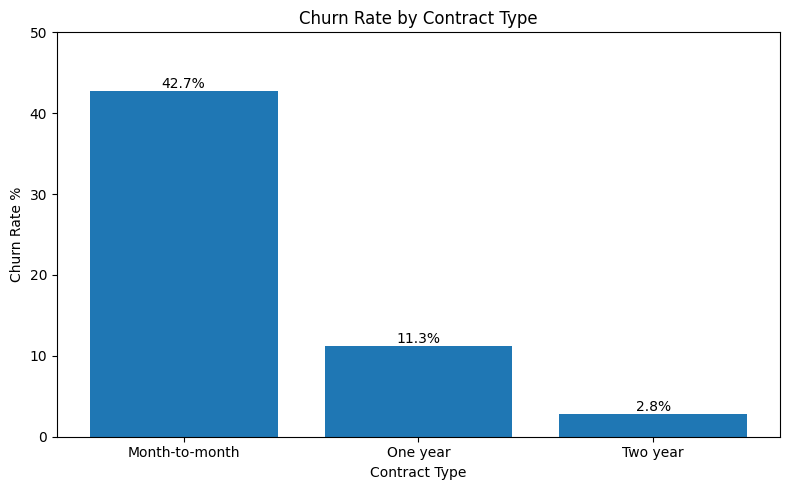

In [16]:
import matplotlib.pyplot as plt

# contract_churn is a frame acquired from the last query in Step 3
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(contract_churn['Contract'], contract_churn['churn_rate'] * 100)

ax.set_title('Churn Rate by Contract Type')
ax.set_xlabel('Contract Type')
ax.set_ylabel('Churn Rate %')
ax.set_ylim(0, 50)

ax.bar_label(bars, fmt='%.1f%%')

plt.tight_layout()
plt.show()


### **Step Six: Use LLMs to generate plain-English summary**

#### We should pair the graph with some text. Rather than manually writing a business summary, we can pass our results into an LLM and have it automatically generate a concise, thorough, and appropriate text

#### There are multiple ways to use LLMs, the easiest and most powerful one is probably to use an SDK provided by a major AI vendor (e.g. Anthropic, OpenAI, Google). Not only are they easy to use, but they are also extremely cheap at the moment. If there are privacy concerns, one could also use a local LLM: they are good options for this use case.

#### I will use Anthropics SDK. It requires an API key, this code loads it from a .env file in the notebook's path. My key will not be published for obvious reasons. If anyone wants to run this portion, they should create a .env file in this directory and insert this text:
ANTHROPIC_API_KEY=[insert_key_here]

In [17]:
from dotenv import load_dotenv
load_dotenv() # Load .env

import anthropic
client = anthropic.Anthropic() # Gets Key from .env

summary_prompt = f"""
You are a business analyst. Summarize the following data findings in 3 sentences for your non-technical executive superiors:

- A customer churn analysis was performed on a telecom dataset of {len(df)} customers
- Logistic Regression model achieved {lr_score:.2%} accuracy predicting churn
- Churn rate by contract type: 
{contract_churn.to_string(index=False)}
"""

message = client.messages.create(
    model="claude-haiku-4-5-20251001",
    max_tokens=150,
    messages=[
        { "role": "user", "content": summary_prompt }
    ])
print(message.content[0].text)

# Churn Analysis Summary

Our analysis of 7,032 telecom customers reveals a significant opportunity to reduce customer attrition by focusing on contract structure. We've developed a predictive model with 80% accuracy to identify at-risk customers, enabling proactive retention efforts. Most critically, month-to-month customers churn at a 43% rate compared to just 3% for two-year contracts, suggesting that incentivizing longer-term commitments could dramatically improve customer retention and lifetime value.


### **Conclusion**

This exploration walked through a typical data science workflow. It displayed how modern tools can transform raw data into business insights through multiple avenues: relational databases that can be queried with SQL, Machine Learning models to predict outcomes, data visualization, and LLM-generated summaries. Using the *Telco Customer Churn* dataset, a strong relationship was found between customer retention and longer contract lenghts. This finding can serve as a business insight that helps executives in the firm make confident, data-backed decisions.